/opt/anaconda3/envs/prokka_env/lib/python3.12/site-packages/adjustText/__init__.py:419: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  ax.figure.draw_without_rendering()
/opt/anaconda3/envs/prokka_env/lib/python3.12/site-packages/adjustText/__init__.py:419: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  ax.figure.draw_without_rendering()
/opt/anaconda3/envs/prokka_env/lib/python3.12/site-packages/adjustText/__init__.py:419: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  ax.figure.draw_without_rendering()
/opt/anaconda3/envs/prokka_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/prokka_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, *

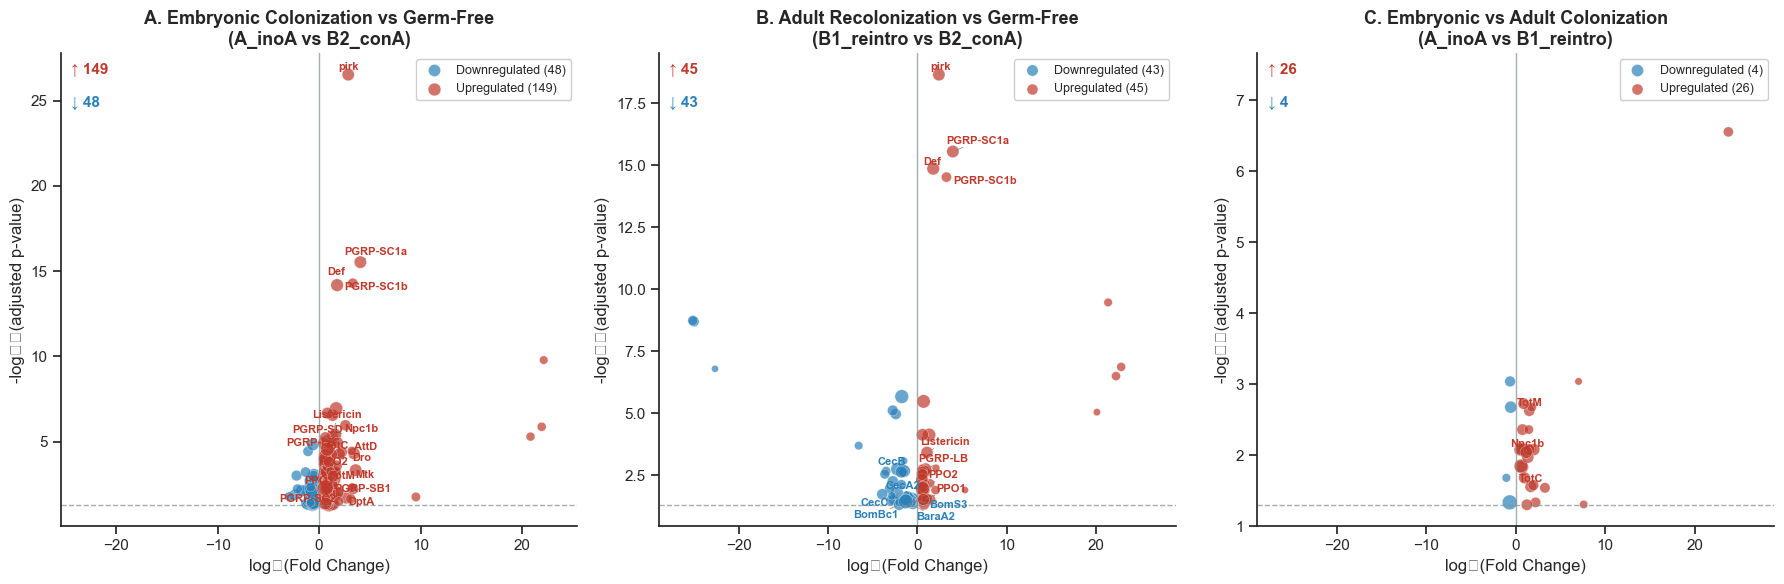

In [7]:
# =============================================================================
# VOLCANO PLOT GENERATION FOR RNA-SEQ DATA
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# Set seaborn theme
sns.set_theme(style="ticks")

# -----------------------------------------------------------------------------
# LOAD DATA
# -----------------------------------------------------------------------------

# Load DESeq2 results for all three comparisons
A_vs_B2 = pd.read_csv('DESeq2_3group_results/A_inoA_vs_B2_conA_significant.csv')
B1_vs_B2 = pd.read_csv('DESeq2_3group_results/B1_reintro_vs_B2_conA_significant.csv')
A_vs_B1 = pd.read_csv('DESeq2_3group_results/A_inoA_vs_B1_reintro_significant.csv')

# Load gene categories
RECOVERED = pd.read_csv('RECOVERED.csv')
NOT_RECOVERED = pd.read_csv('NOT_RECOVERED.csv')
UNIQUE = pd.read_csv('UNIQUE.csv')

# Get gene IDs for each category
recovered_ids = set(RECOVERED['gene_id'].tolist())
not_recovered_ids = set(NOT_RECOVERED['gene_id'].tolist())
unique_ids = set(UNIQUE['gene_id'].tolist())

# DESeq2 results files
deseq_files = {
    'A_inoA_vs_B2_conA': 'DESeq2_3group_results/A_inoA_vs_B2_conA_significant.csv',
    'B1_reintro_vs_B2_conA': 'DESeq2_3group_results/B1_reintro_vs_B2_conA_significant.csv',
    'A_inoA_vs_B1_reintro': 'DESeq2_3group_results/A_inoA_vs_B1_reintro_significant.csv'
}

# Load DESeq2 data
deseq_data = {}
for name, path in deseq_files.items():
    df = pd.read_csv(path)
    if 'Unnamed: 0' in df.columns:
        df = df.rename(columns={'Unnamed: 0': 'gene'})
    elif 'gene_id' in df.columns:
        df = df.rename(columns={'gene_id': 'gene'})
    deseq_data[name] = df

# -----------------------------------------------------------------------------
# VOLCANO PLOT FUNCTION
# -----------------------------------------------------------------------------

def create_volcano_plot(df, title, ax, key_genes=None, label_top_n=15):
    """
    Create a volcano plot with:
    - Upregulated genes in red
    - Downregulated genes in blue
    - Dot size reflects expression level: size = log10(baseMean + 1) × 30

    Parameters:
    -----------
    df : DataFrame with columns: baseMean, log2FoldChange, padj, gene_name
    title : str, plot title
    ax : matplotlib axis
    key_genes : list, optional - specific genes to label
    label_top_n : int, number of top genes to label if key_genes not provided
    """

    df = df.copy()
    df['-log10(padj)'] = -np.log10(df['padj'])

    # Calculate dot size based on expression level
    # Formula: size = log10(baseMean + 1) × 30
    df['size'] = np.log10(df['baseMean'] + 1) * 30

    # Classify genes
    df['direction'] = 'Not Significant'
    df.loc[(df['log2FoldChange'] > 0) & (df['padj'] < 0.05), 'direction'] = 'Upregulated'
    df.loc[(df['log2FoldChange'] < 0) & (df['padj'] < 0.05), 'direction'] = 'Downregulated'

    up_count = (df['direction'] == 'Upregulated').sum()
    down_count = (df['direction'] == 'Downregulated').sum()

    # Colors
    colors = {'Upregulated': '#C0392B', 'Downregulated': '#2980B9', 'Not Significant': '#D5D8DC'}

    # Plot each category
    for direction in ['Not Significant', 'Downregulated', 'Upregulated']:
        subset = df[df['direction'] == direction]
        if len(subset) > 0:
            ax.scatter(
                subset['log2FoldChange'],
                subset['-log10(padj)'],
                s=subset['size'],
                c=colors[direction],
                alpha=0.7 if direction != 'Not Significant' else 0.4,
                edgecolors='white',
                linewidths=0.3,
                label=f'{direction} ({len(subset)})'
            )

    # Threshold lines
    ax.axhline(y=-np.log10(0.05), color='#7F8C8D', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=0, color='#7F8C8D', linestyle='-', linewidth=1, alpha=0.7)

    # Label genes
    sig_genes = df[df['padj'] < 0.05].copy()

    if key_genes:
        genes_to_label = sig_genes[sig_genes['gene_name'].isin(key_genes)]
    else:
        sig_genes['abs_lfc'] = np.abs(sig_genes['log2FoldChange'])
        sig_genes = sig_genes.sort_values(['-log10(padj)', 'abs_lfc'], ascending=[False, False])
        top_up = sig_genes[sig_genes['log2FoldChange'] > 0].head(label_top_n // 2 + 3)
        top_down = sig_genes[sig_genes['log2FoldChange'] < 0].head(label_top_n // 2)
        genes_to_label = pd.concat([top_up, top_down])

    texts = []
    for _, row in genes_to_label.iterrows():
        color = '#C0392B' if row['log2FoldChange'] > 0 else '#2980B9'
        texts.append(ax.text(
            row['log2FoldChange'],
            row['-log10(padj)'],
            row['gene_name'],
            fontsize=8,
            fontweight='bold',
            color=color,
            ha='center',
            va='bottom'
        ))

    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # Formatting
    ax.set_xlabel('log₂(Fold Change)', fontsize=12)
    ax.set_ylabel('-log₁₀(adjusted p-value)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95)

    # Count annotations
    ax.text(0.02, 0.98, f'↑ {up_count}', transform=ax.transAxes, fontsize=11, 
            color='#C0392B', fontweight='bold', va='top')
    ax.text(0.02, 0.91, f'↓ {down_count}', transform=ax.transAxes, fontsize=11, 
            color='#2980B9', fontweight='bold', va='top')

    x_max = max(abs(df['log2FoldChange'].min()), abs(df['log2FoldChange'].max())) * 1.15
    ax.set_xlim(-x_max, x_max)

    sns.despine(ax=ax)

    return ax

# -----------------------------------------------------------------------------
# KEY IMMUNE GENES TO HIGHLIGHT
# -----------------------------------------------------------------------------

key_immune_genes = [
    'PGRP-SC1a', 'PGRP-SC1b', 'PGRP-LB', 'PGRP-SD', 'PGRP-SB1', 'PGRP-SC2',
    'Def', 'Dro', 'Mtk', 'AttD', 'DptA', 'Listericin',
    'CecA2', 'CecB', 'CecC', 'BomBc1', 'BomS3', 'BaraA2',
    'PPO1', 'PPO2', 'pirk', 'TotM', 'TotC', 'Npc1b'
]

# -----------------------------------------------------------------------------
# CREATE COMBINED FIGURE
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot A: A_inoA vs B2_conA
create_volcano_plot(
    A_vs_B2, 
    'A. Embryonic Colonization vs Germ-Free\n(A_inoA vs B2_conA)',
    axes[0],
    key_genes=key_immune_genes
)

# Plot B: B1_reintro vs B2_conA
create_volcano_plot(
    B1_vs_B2, 
    'B. Adult Recolonization vs Germ-Free\n(B1_reintro vs B2_conA)',
    axes[1],
    key_genes=key_immune_genes
)

# Plot C: A_inoA vs B1_reintro
create_volcano_plot(
    A_vs_B1, 
    'C. Embryonic vs Adult Colonization\n(A_inoA vs B1_reintro)',
    axes[2],
    key_genes=key_immune_genes
)

plt.tight_layout()
#plt.savefig('Figure_Volcano_Plots_Manuscript.png', dpi=300, bbox_inches='tight')
plt.show()


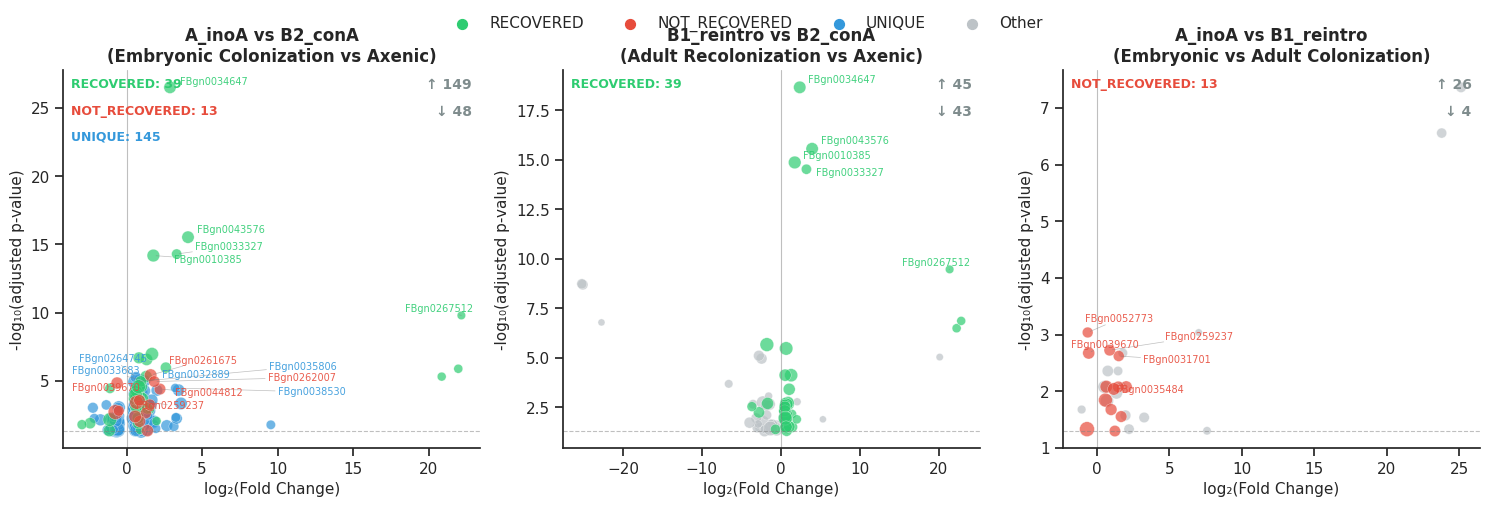

In [8]:
"""
Volcano Plot Code with RECOVERED/NOT_RECOVERED/UNIQUE Category Labels
"""
sns.set_style("ticks")
plt.rcParams['font.family'] = 'DejaVu Sans'  # Or 'Arial' if available
plt.rcParams['font.size'] = 10

# Color scheme for categories
COLORS = {
    'RECOVERED': '#2ECC71',      # Green
    'NOT_RECOVERED': '#E74C3C',  # Red
    'UNIQUE': '#3498DB',         # Blue
    'Other': '#BDC3C7'           # Gray
}

# Extract gene names (handle different column formats)
def extract_genes(df):
    if 'Unnamed: 0' in df.columns:
        return set(df['Unnamed: 0'].tolist())
    elif 'gene' in df.columns:
        return set(df['gene'].tolist())
    else:
        return set(df.iloc[:, 0].tolist())

recovered_genes = extract_genes(RECOVERED)
not_recovered_genes = extract_genes(NOT_RECOVERED)
unique_genes = extract_genes(UNIQUE)

# =============================================================================
# VOLCANO PLOT FUNCTION WITH CATEGORIES
# =============================================================================
def create_volcano_with_categories(df, title, ax, recovered_genes, not_recovered_genes, 
                                    unique_genes, label_top_n=10, show_category_labels=True):
    """
    Create volcano plot with RECOVERED/NOT_RECOVERED/UNIQUE category coloring.

    Parameters:
    -----------
    df : DataFrame
        Must contain columns: 'gene', 'log2FoldChange', 'padj', 'baseMean'
    title : str
        Plot title
    ax : matplotlib axis
        Axis to plot on
    recovered_genes : set
        Gene names in RECOVERED category
    not_recovered_genes : set
        Gene names in NOT_RECOVERED category
    unique_genes : set
        Gene names in UNIQUE category
    label_top_n : int
        Number of top genes to label per category (by significance)
    show_category_labels : bool
        Whether to show category count annotations

    Returns:
    --------
    ax : matplotlib axis
    """

    # Calculate -log10(padj)
    df = df.copy()
    df['neg_log10_padj'] = -np.log10(df['padj'].replace(0, 1e-300))

    # Calculate dot sizes: size = log10(baseMean + 1) × 30
    df['size'] = np.log10(df['baseMean'] + 1) * 30

    # Assign categories
    def assign_category(gene):
        if gene in recovered_genes:
            return 'RECOVERED'
        elif gene in not_recovered_genes:
            return 'NOT_RECOVERED'
        elif gene in unique_genes:
            return 'UNIQUE'
        else:
            return 'Other'

    df['category'] = df['gene'].apply(assign_category)

    # Plot order: Other first (background), then categories on top
    plot_order = ['Other', 'UNIQUE', 'RECOVERED', 'NOT_RECOVERED']

    for cat in plot_order:
        subset = df[df['category'] == cat]
        if len(subset) > 0:
            ax.scatter(subset['log2FoldChange'], subset['neg_log10_padj'],
                      s=subset['size'], c=COLORS[cat], alpha=0.7,
                      edgecolors='white', linewidths=0.3, 
                      label=cat if cat != 'Other' else None)

    # Add threshold lines
    ax.axhline(y=-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

    # Labels
    ax.set_xlabel('log₂(Fold Change)', fontsize=11)
    ax.set_ylabel('-log₁₀(adjusted p-value)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

    # Count genes by category
    recovered_count = len(df[df['category'] == 'RECOVERED'])
    not_recovered_count = len(df[df['category'] == 'NOT_RECOVERED'])
    unique_count = len(df[df['category'] == 'UNIQUE'])

    # Add category count annotations (top-left)
    if show_category_labels:
        y_pos = 0.98
        if recovered_count > 0:
            ax.text(0.02, y_pos, f'RECOVERED: {recovered_count}', transform=ax.transAxes, 
                   fontsize=9, color=COLORS['RECOVERED'], fontweight='bold', va='top')
            y_pos -= 0.07
        if not_recovered_count > 0:
            ax.text(0.02, y_pos, f'NOT_RECOVERED: {not_recovered_count}', transform=ax.transAxes, 
                   fontsize=9, color=COLORS['NOT_RECOVERED'], fontweight='bold', va='top')
            y_pos -= 0.07
        if unique_count > 0:
            ax.text(0.02, y_pos, f'UNIQUE: {unique_count}', transform=ax.transAxes, 
                   fontsize=9, color=COLORS['UNIQUE'], fontweight='bold', va='top')

    # Add up/down count annotations (top-right)
    up_count = len(df[df['log2FoldChange'] > 0])
    down_count = len(df[df['log2FoldChange'] < 0])
    ax.text(0.98, 0.98, f'↑ {up_count}', transform=ax.transAxes, fontsize=10, 
           color='#7F8C8D', fontweight='bold', va='top', ha='right')
    ax.text(0.98, 0.91, f'↓ {down_count}', transform=ax.transAxes, fontsize=10, 
           color='#7F8C8D', fontweight='bold', va='top', ha='right')

    # Label top genes from each category
    texts = []
    for cat in ['RECOVERED', 'NOT_RECOVERED', 'UNIQUE']:
        cat_df = df[df['category'] == cat].nlargest(label_top_n, 'neg_log10_padj')
        for _, row in cat_df.iterrows():
            texts.append(ax.text(row['log2FoldChange'], row['neg_log10_padj'], 
                                row['gene'], fontsize=7, color=COLORS[cat], alpha=0.9))

    # Adjust text to avoid overlaps
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, lw=0.5))

    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    return ax

# =============================================================================
# GENERATE FIGURES
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

titles = [
    'A_inoA vs B2_conA\n(Embryonic Colonization vs Axenic)',
    'B1_reintro vs B2_conA\n(Adult Recolonization vs Axenic)',
    'A_inoA vs B1_reintro\n(Embryonic vs Adult Colonization)'
]
comparisons = ['A_inoA_vs_B2_conA', 'B1_reintro_vs_B2_conA', 'A_inoA_vs_B1_reintro']

for ax, comp, title in zip(axes, comparisons, titles):
    create_volcano_with_categories(
        deseq_data[comp], title, ax,
        recovered_genes, not_recovered_genes, unique_genes,
        label_top_n=5
    )


handles = [
    plt.scatter([], [], c=COLORS['RECOVERED'], s=50, label='RECOVERED'),
    plt.scatter([], [], c=COLORS['NOT_RECOVERED'], s=50, label='NOT_RECOVERED'),
    plt.scatter([], [], c=COLORS['UNIQUE'], s=50, label='UNIQUE'),
    plt.scatter([], [], c=COLORS['Other'], s=50, label='Other')
]
fig.legend(handles=handles, loc='upper center', ncol=4, 
            bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout()
plt.show()
plt.subplots_adjust(top=0.88)
#plt.savefig('Volcano_Plots_Categories_3Panel.png', dpi=300, bbox_inches='tight')
plt.close()

